In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.PDB import PDBParser, Superimposer

Loading reference: /data/leuven/368/vsc36835/thesis/PDB_distributions/pdbs_example/1DPW.pdb...
Found 2 predicted structures.

--- Calculating RMSD vs True Structure ---
--- Calculating Pairwise RMSD (Diversity) ---

STATISTICAL SUMMARY
Total Predictions: 2

[Accuracy vs True Structure]
  Closest (Best):  1DPW.pdb (RMSD: 0.000 Å)
  Farthest (Worst): 1DPX.pdb (RMSD: 0.218 Å)
  Mean RMSD:       0.109 Å
  Std Dev:         0.109 Å

[Population Diversity (Pairwise)]
  Mean Pairwise Dist: 0.218 Å (Higher = more diverse predictions)
  Min Pairwise Dist:  0.218 Å


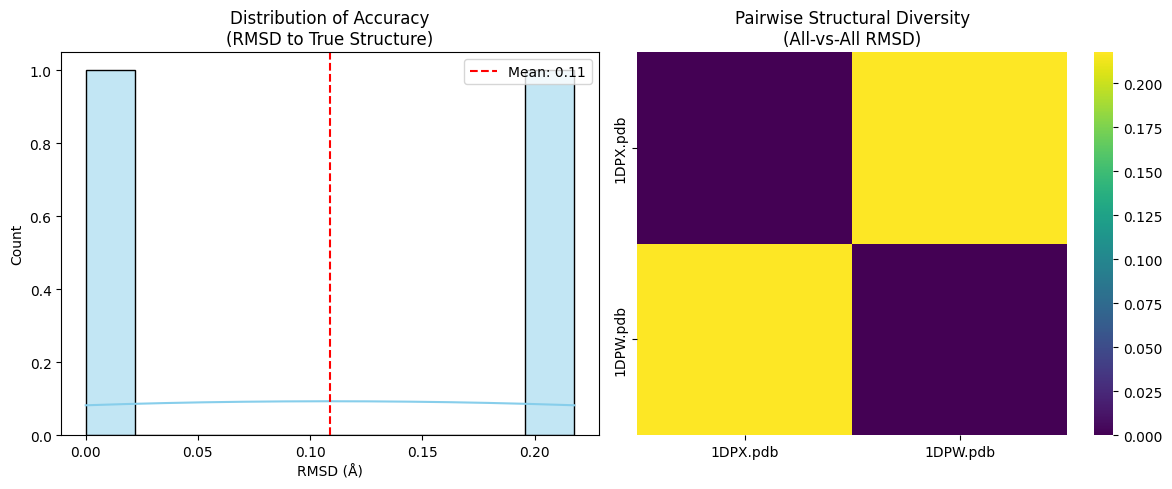

In [57]:
# ver useful doumentation link is https://biopython.org/docs/latest/Tutorial/chapter_pdb.html
def get_ca_atoms(structure):
    """
    Extracts Alpha Carbon (CA) atoms from the first model of a structure.
    """
    atoms = []
    # We iterate over the first model (model[0])
    # In NMR for example there are often many models each havign diffrent conformation of the same protein. we ignroe this and just use the  first one as we also geneally will only have one from crystalization 
    for chain in structure[0]:
        for residue in chain:
            # For standart maino acids id[0] will be ' '
            # documentaion https://biopython.org/docs/dev/Tutorial/chapter_pdb.html seach hetero-field 
            # Skip heteroatoms (water, ligands)
            if residue.id[0] != ' ':
                continue

            # based on the documentation:
            # if there is a calcilum atom it will also be called CA in the pdb but with diffrent spaceing. pdb usually have calculum atom mas "CA.." and Alpha carbons as ".CA." 
            # if there is not conflict (so only calclium or only alpha carbons) then they will only called CA otherwise the sapcing is kept. wither way we can get thefull name with spacing of the atom using atom.fullname
            # for now i just do it in the standd way expecting just one CA but do osme exception if weid things happen. it they do might wannt just go over the full name of the atoms and look for ".CA."
            if residue.has_id("CA"):
                if not is_aa(residue):
                    raise Exception("has CA but not an AA; strange but possible tbh can just remove this check later if it makign issues")
                atoms.append(residue['CA'])
            else:
                if residue.has_id(" CA ") or residue.has_id(" CA"):
                    raise Exception("There is both calcilum and carbon atom")
    return atoms

def calculate_rmsd(ref_structure, sample_structure):
    """
    Superimposes sample_structure onto ref_structure and calculates RMSD.
    """
    # Get CA atoms
    ref_atoms = get_ca_atoms(ref_structure)
    sample_atoms = get_ca_atoms(sample_structure)

    # Check for residue mismatch
    if len(ref_atoms) != len(sample_atoms):
        raise Exception(f"Atom count mismatch ({len(ref_atoms)} vs {len(sample_atoms)}). RMSD may be invalid without sequence alignment.")
    
    # Initialize Superimposer
    # assuming that there is the same number of atoms in both stucture. if there is not and we need to align we need to use CEAligner  instead of this
    # The algorithm used by Superimposer comes from Golub & Van Loan [Golub1989] and makes use of singular value decomposition (this is implemented in the general Bio.SVDSuperimposer module).
    super_imposer = Superimposer()
    super_imposer.set_atoms(ref_atoms, sample_atoms)
    
    ### a possible alternative to ths algotitehm si to use In addition to using the Superimposer object, you can also choose to use the QCPSuperimposer object, which is faster than the standard Superimposer. The algorithm for the QCPSuperimposer comes from Theobald [Theobald2005] and rapidly calculates the minimum RMSD by using the quaternion characteristic polynomial (QCP).

    # Apply rotation/translation to the sample structure
    super_imposer.apply(sample_structure.get_atoms())
    
    # Return the RMSD
    return super_imposer.rms

def main():
    # --- CONFIGURATION ---
    true_pdb_path = "/data/leuven/368/vsc36835/thesis/PDB_distributions/pdbs_example/1DPW.pdb"  # Replace with your true PDB file
    predicted_dir = "/data/leuven/368/vsc36835/thesis/PDB_distributions/pdbs_example/"        # Folder containing predicted PDBs
    # ---------------------

    parser = PDBParser(QUIET=True)
    
    # Load Reference Structure
    if not os.path.exists(true_pdb_path):
        print(f"Error: True structure file '{true_pdb_path}' not found.")
        return
        
    print(f"Loading reference: {true_pdb_path}...")
    # the "ground true" is the name that we give the structure in the file
    true_struct = parser.get_structure("ground true", true_pdb_path)
    
    # Load Predicted Structures
    pred_files = [f for f in os.listdir(predicted_dir) if f.endswith(".pdb")]
    pred_structs = []
    
    print(f"Found {len(pred_files)} predicted structures.")
    for f in pred_files:
        path = os.path.join(predicted_dir, f)
        struct = parser.get_structure(f, path)
        pred_structs.append((f, struct))

    # Calculate RMSD: Predicted vs True
    results_vs_true = []
    print("\n--- Calculating RMSD vs True Structure ---")
    
    for name, p_struct in pred_structs:
        rmsd = calculate_rmsd(true_struct, p_struct)
        results_vs_true.append({'name': name, 'rmsd': rmsd})

    # Sort by RMSD (Best to Worst)
    results_vs_true.sort(key=lambda x: x['rmsd'])
    
    # Calculate Pairwise RMSD (Diversity)
    print("--- Calculating Pairwise RMSD (Diversity) ---")
    num_preds = len(pred_structs)
    pairwise_matrix = np.zeros((num_preds, num_preds))
    pairwise_rmsds = []

    for i in range(num_preds):
        for j in range(i + 1, num_preds):
            rmsd = calculate_rmsd(pred_structs[i][1], pred_structs[j][1])
            pairwise_matrix[i, j] = rmsd
            pairwise_matrix[j, i] = rmsd
            pairwise_rmsds.append(rmsd)

    # Output Statistics
    rmsd_values = [x['rmsd'] for x in results_vs_true]
    
    print("\n" + "="*40)
    print("STATISTICAL SUMMARY")
    print("="*40)
    
    print(f"Total Predictions: {len(rmsd_values)}")
    print(f"\n[Accuracy vs True Structure]")
    print(f"  Closest (Best):  {results_vs_true[0]['name']} (RMSD: {results_vs_true[0]['rmsd']:.3f} Å)")
    print(f"  Farthest (Worst): {results_vs_true[-1]['name']} (RMSD: {results_vs_true[-1]['rmsd']:.3f} Å)")
    print(f"  Mean RMSD:       {np.mean(rmsd_values):.3f} Å")
    print(f"  Std Dev:         {np.std(rmsd_values):.3f} Å")

    print(f"\n[Population Diversity (Pairwise)]")
    if pairwise_rmsds:
        print(f"  Mean Pairwise Dist: {np.mean(pairwise_rmsds):.3f} Å (Higher = more diverse predictions)")
        print(f"  Min Pairwise Dist:  {np.min(pairwise_rmsds):.3f} Å")
    
    # Visualization
    plt.figure(figsize=(12, 5))

    # Plot 1: Histogram of Accuracy
    plt.subplot(1, 2, 1)
    sns.histplot(rmsd_values, kde=True, bins=10, color='skyblue')
    plt.axvline(np.mean(rmsd_values), color='red', linestyle='--', label=f'Mean: {np.mean(rmsd_values):.2f}')
    plt.title('Distribution of Accuracy\n(RMSD to True Structure)')
    plt.xlabel('RMSD (Å)')
    plt.legend()

    # Plot 2: Heatmap of Pairwise Differences
    plt.subplot(1, 2, 2)
    # Create labels for heatmap (shortened names)
    labels = [x[0][:10] for x in pred_structs] 
    sns.heatmap(pairwise_matrix, xticklabels=labels, yticklabels=labels, cmap="viridis")
    plt.title('Pairwise Structural Diversity\n(All-vs-All RMSD)')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [51]:
# a = list(residue.get_atoms())[0]
a.fullname

' O  '

In [54]:
len(atoms_classic)

129

In [35]:
len(atoms_classic)

129